# run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

### Set up and getting data

In [1]:
# %%capture
# aaa
!pip install xgboost
!pip install imbalanced-learn
!pip install catboost
!pip install optuna
!pip install torch
import pandas as pd
import numpy as np
import time
from google.cloud import bigquery
from xgboost import XGBClassifier
import catboost
from catboost import CatBoostClassifier, Pool, metrics, cv
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
import random
import torch
import optuna

random.seed(35)
np.random.seed(35)

client = bigquery.Client()

def lift_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    expected_positives = y_true.sum() * 0.01
    lift = actual_positives / expected_positives if expected_positives != 0 else 0
    return lift

def true_positives_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    return actual_positives

def num_samples_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    return top_1_percent

def f1_score_top_1_percent(y_true, y_pred_proba):
    top_1_percent = int(0.01 * len(y_true))
    top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
    y_true_top = y_true.iloc[top_indices]
    y_pred_top = np.ones(top_1_percent)
    return f1_score(y_true_top, y_pred_top)


# Make scorers
scorers = {
    'lift@1%': make_scorer(lift_at_1_percent, needs_proba=True),
    'f1@1%': make_scorer(f1_score_top_1_percent, needs_proba=True),
    'true_positives@1%': make_scorer(true_positives_at_1_percent, needs_proba=True),
    'num_samples@1%': make_scorer(num_samples_at_1_percent, needs_proba=True),
    'AUC':'roc_auc',
    'weighted AUC':make_scorer(roc_auc_score, needs_proba = True, multi_class = 'ovr', average = 'weighted') 
}

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [2]:
# Get features
sql = """
SELECT
    f.* EXCEPT (asdb_plan_key, post_mnths, first_prv_dt, last_prv_dt, index_dt)
    , e.* EXCEPT (individual_id)
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_non_embedding_features` AS f
LEFT JOIN
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_embeddings` AS e
        ON f.asdb_member_key = e.individual_id
WHERE 1=1
    AND NOT asdb_plan_key IN (33, 54)
    AND post_mnths >= 6
    
"""
df_og = client.query(sql).to_dataframe() 

df_og.shape
#2,542,308 members who qualify with 564 features we are exploring

(2542308, 561)

In [3]:
# Get labels (acute IP) stay (0=no, 1=yes) in the 6 months post-index date
sql = """
SELECT
    asdb_member_key
    , acute_ip_flag
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_outcome_ip` AS o
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome_og = client.query(sql).to_dataframe() 
outcome_og.shape

(2542308, 2)

### Data Preprocessing

In [4]:
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float
import re

emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df_og.columns if re.match(emb_pattern ,col)]
df_og[emb_col] = df_og[emb_col].fillna(0)

for c in df_og.columns: 
    dt = df_og[c].dtype
    if is_integer(dt) or is_float(dt):
        df_og[c]=df_og[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df_og[c]= df_og[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)

In [5]:
df = df_og
outcome = outcome_og


# COMMENT OUT WHEN TESTING WITH SUBSET
# _, df, _, outcome = train_test_split(df_og, outcome_og, test_size=0.01, random_state=100) # Sample small subset of data for testing purposes


df.shape
outcome.shape

(2542308, 2)

In [6]:
df = df.set_index('asdb_member_key')
outcome = outcome.set_index('asdb_member_key')
merged = df.merge(outcome, on='asdb_member_key', how='left')

assert merged.shape[1] == 561, "The number of columns in the DataFrame does not match expected feature + label count" # Splitting the data into train and test sets X_train, X_test, y_train, y_test = train_test_split( merged.iloc[:, :560], # Selecting first 560 columns as features, adjust if column count changes merged['acute_ip_flag'], # Using direct column selection for clarity test_size=0.2, random_state=100 )


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(merged.iloc[:, 1:560], merged.loc[:, 'acute_ip_flag'], test_size=0.2, random_state=35, stratify=merged.loc[:, 'acute_ip_flag'])
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=35, stratify=y_test)

# 80:10:10 split

### Undersampling Tests (only run for finding optimal downsample ratio)

In [ ]:
ratios = [0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]  # FILL IN RATIOS TO TEST
seeds = [53]  # Random seeds for reproducibility

valid_pool = Pool(X_val, y_val, cat_features=string_columns)
results = []

for r in ratios:
    total = 0
    for s in seeds:
        undersample = RandomUnderSampler(sampling_strategy=r, random_state=s)  
        steps = [
            ('u', undersample)
        ]
        pipeline = Pipeline(steps=steps)
        X_train_u, y_train_u = pipeline.fit_resample(X_train, y_train)
        
        catboost_model = CatBoostClassifier(random_seed=53, thread_count=15, verbose=0)
        catboost_model.fit(X_train_u, y_train_u, eval_set=valid_pool, verbose=0, plot=False, cat_features=string_columns)
        print("done fit")
        
        y_pred_val = catboost_model.predict_proba(X_val)[:, 1]
        y_pred_test = catboost_model.predict_proba(X_test)[:, 1]
        
        # Ensure y_test is aligned properly by resetting its index
        y_test_reset = y_test.reset_index(drop=True)

        # Sort the indices based on predicted probabilities
        idx = np.argsort(y_pred_test)[::-1]
        top_1_percent = int(0.01 * len(y_test_reset))  # 1% of test data size

        # Use reset index to ensure alignment
        predicted_top_1_percent = y_test_reset.iloc[idx][:top_1_percent]
        actual_positives_top_1_percent = predicted_top_1_percent.sum()

        # Calculate expected positives
        expected_positives = y_test_reset.sum() * 0.01

        # Calculate lift
        lift = actual_positives_top_1_percent / expected_positives
        
       
        results.append((r, s, lift))
        print("one iteration")



In [ ]:
# No undersampling
catboost_model = CatBoostClassifier(random_seed=35, thread_count=15, verbose=0)
catboost_model.fit(X_train, y_train, eval_set=valid_pool, verbose=0, plot=False, cat_features=string_columns)
print("done fit")

y_pred_val = catboost_model.predict_proba(X_val)[:, 1]
y_pred_test = catboost_model.predict_proba(X_test)[:, 1]

# Ensure y_test is aligned properly by resetting its index
y_test_reset = y_test.reset_index(drop=True)

# Sort the indices based on predicted probabilities
idx = np.argsort(y_pred_test)[::-1]
top_1_percent = int(0.01 * len(y_test_reset))  # 1% of test data size

# Use reset index to ensure alignment
predicted_top_1_percent = y_test_reset.iloc[idx][:top_1_percent]
actual_positives_top_1_percent = predicted_top_1_percent.sum()

# Calculate expected positives
expected_positives = y_test_reset.sum() * 0.01

# Calculate lift
lift = actual_positives_top_1_percent / expected_positives
        
       
results.append((0, 0, lift)) # 0, 0 := no sampling
print("one iteration, no sample")

## No undersampling but class weights
class_weights = { # wj= n_samples / (n_classes * n_samplesj)
    0: 1,  #  majority class is 0
    1: (len(y_train) / (2 * y_train.sum()))  # Weight for the minority class
}

catboost_model = CatBoostClassifier(random_seed=35, thread_count=15, verbose=0, class_weights = class_weights)
catboost_model.fit(X_train, y_train, eval_set=valid_pool, verbose=0, plot=False, cat_features=string_columns)
print("done fit")

y_pred_val = catboost_model.predict_proba(X_val)[:, 1]
y_pred_test = catboost_model.predict_proba(X_test)[:, 1]
# Ensure y_test is aligned properly by resetting its index
y_test_reset = y_test.reset_index(drop=True)

# Sort the indices based on predicted probabilities
idx = np.argsort(y_pred_test)[::-1]
top_1_percent = int(0.01 * len(y_test_reset))  # 1% of test data size

# Use reset index to ensure alignment
predicted_top_1_percent = y_test_reset.iloc[idx][:top_1_percent]
actual_positives_top_1_percent = predicted_top_1_percent.sum()

# Calculate expected positives
expected_positives = y_test_reset.sum() * 0.01

# Calculate lift
lift = actual_positives_top_1_percent / expected_positives
        
       
results.append((999, 999, lift))
print("one iteration, class weights")
        
        

In [ ]:
# results_df = pd.DataFrame(results, columns=['Ratio', 'Seed', '1% Lift'])

In [ ]:
# print(results)

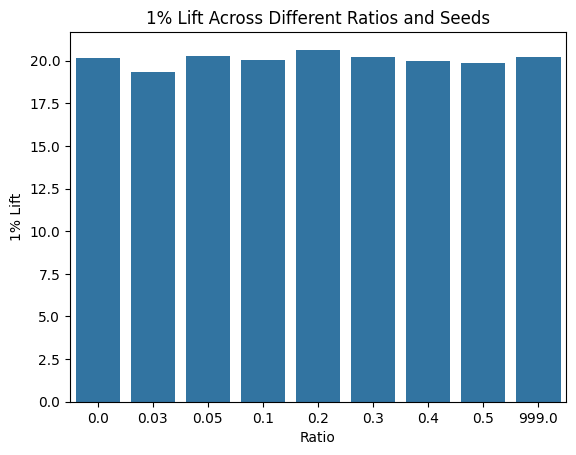

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=results_df, x='Ratio', y='1% Lift')
plt.title('1% Lift Across Different Ratios and Seeds')
plt.show()

results_df.to_csv('lift_results.csv', index=False)


In [15]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("Training Set:")
check_label_distribution(y_train)

print("\nValidation Set:")
check_label_distribution(y_val)

print("\nTest Set:")
check_label_distribution(y_test)


Training Set:
174350 34870 0.2

Validation Set:
249872 4359 0.017444931805084204

Test Set:
249872 4359 0.017444931805084204


(249872, 4359, 0.017444931805084204)

### RFE Tests (only run for generating list of selected features)

In [ ]:
undersample = RandomUnderSampler(sampling_strategy=0.2, random_state=53)  # We determined above that 0.2 is optimal ratio
steps = [
    ('u', undersample)
]
pipeline = Pipeline(steps=steps)
X_train, y_train = pipeline.fit_resample(X_train, y_train)

In [9]:
string_columns = X_train.select_dtypes(include='object').columns.tolist() # CatBoost handles categorical features natively, thus we need to specify categorical columns
# TODO: Should this include just string features or all categorical features?

In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for col in string_columns:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_val[col] = label_encoder.fit_transform(X_val[col])
    X_test[col] = label_encoder.fit_transform(X_test[col])
    # print(col)

# Convert labels format
y_train = y_train.astype('int')
y_val = y_val.astype('int')
y_test = y_test.astype('int')


In [11]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("Training Set:")
check_label_distribution(y_train)

print("\nValidation Set:")
check_label_distribution(y_val)

print("\nTest Set:")
check_label_distribution(y_test)

# y_train.value_counts()
# X_train.value_counts()


Training Set:
174350 34870 0.2

Validation Set:
249872 4359 0.017444931805084204

Test Set:
249872 4359 0.017444931805084204


(249872, 4359, 0.017444931805084204)

In [68]:
'''
RFE CODE
'''

catboost_model_rfe = CatBoostClassifier(
    random_seed=53,
    thread_count=15,
    verbose=1,
)

rfecv = RFECV(
    estimator=catboost_model_rfe,
    step=10, # Num features removed for each step
    cv=StratifiedKFold(3), # Num folds
    scoring="roc_auc",
    min_features_to_select=1,
    n_jobs=-1, # Use all processors
)

# with suppress_stdout_stderr():
rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
# print(f"Feature rankings: {rfecv.ranking_}")


X_train = rfecv.transform(X_train) 
X_val = rfecv.transform(X_val) 
X_test = rfecv.transform(X_test)

57


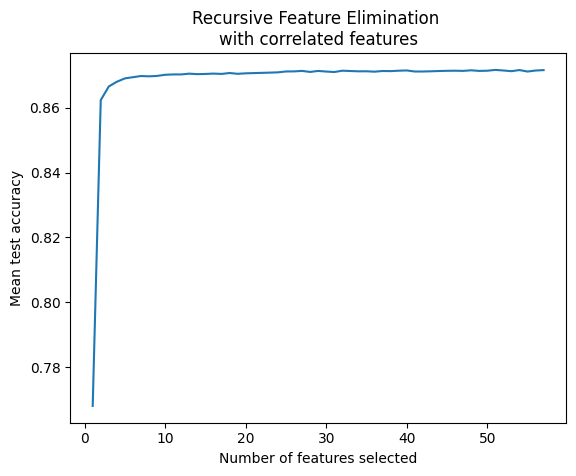

In [72]:


n_features = list(range(1, len(rfecv.cv_results_['mean_test_score']) + 1))
for i in range(len(n_features)):
    n_features[i]=n_features[i]*10
    
mean_test_scores = rfecv.cv_results_['mean_test_score']
cv_results = pd.DataFrame({
    'n_features': n_features,
    'mean_test_score': mean_test_scores
})

plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.plot(cv_results["n_features"], cv_results["mean_test_score"])
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()


# TODO: GET LIST OF FEATURES

In [84]:
print(selected_features)
len(selected_features)
with open('catboost_selected_features.txt', 'w') as file:
    # Join the list elements into a single string with a newline character
    data_to_write = '\n'.join(selected_features)
     
    # Write the data to the file
    file.write(data_to_write)

Index(['coa_population_group', 'sum_ed_visits_yr1', 'ed_flag_yr1',
       'sum_avoidable_yr1', 'sum_unnecessary_yr1', 'sum_preventable_yr1',
       'low_sev_ed_visits_yr1', 'low_med_sev_ed_visits_yr1',
       'med_sev_ed_visits_yr1', 'med_high_sev_ed_visits_yr1',
       ...
       'emb246', 'emb247', 'emb248', 'emb249', 'emb250', 'emb251', 'emb252',
       'emb253', 'emb254', 'emb255'],
      dtype='object', length=499)


In [12]:
import pandas as pd
# open file in read mode
f = open('catboost_selected_features.txt', 'r')
selected_features = [x.strip() for x in f.readlines()]
print(len(selected_features))
f.close()
X_train_df = pd.DataFrame(X_train, columns = df.columns)

X_train = X_train_df[selected_features]

X_val_df = pd.DataFrame(X_val, columns = df.columns)

X_val = X_val_df[selected_features]

X_test_df = pd.DataFrame(X_test, columns = df.columns)

X_test = X_test_df[selected_features]

# X_test

499


In [24]:
X_train.shape

(209220, 499)

### Optuna Hyperparameterization (only run for determining optimal hyperparameters)

In [ ]:
# Optuna
import logging
logging.basicConfig(filename='optuna_catboost.log', level=logging.INFO)

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'iterations': trial.suggest_int('iterations', 100, 7000),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True), # prevent overfitting
        'depth': trial.suggest_int('depth', 4, 12),
        # number of trees
        # early stopping
        'random_seed': 53,
        'verbose': 0,
        'thread_count':15
    }
    
    model = CatBoostClassifier(**params)
    valid_pool = Pool(X_val, y_val)#, cat_features=string_columns
    model.fit(X_train, y_train, eval_set=valid_pool, verbose=0, plot=False, use_best_model=True)#, cat_features=string_columns
    y_pred_test = model.predict_proba(X_test)[:, 1]
    roc_auc_test = roc_auc_score(y_test, y_pred_test)
    
    logging.info(f"Trial {trial.number} AUC: {roc_auc_test} Params: {params}")
    
    study_results = study.trials_dataframe(attrs=('number', 'value', 'params', 'state'))# Saving the results to a CSV file
    study_results.to_csv('optuna_results.csv', index=False)
    
    return roc_auc_test

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=75) # trials must be at least 50
print("Number of finished trials: ", len(study.trials))

best_trial = study.best_trial
print("Best trial:")
print(" AUC:", best_trial.value)
print(" Params:", best_trial.params)

# Log the best result
logging.info(f"Best AUC: {best_trial.value} with params: {best_trial.params}")
study_results = study.trials_dataframe(attrs=('number', 'value', 'params', 'state'))# Saving the results to a CSV file
study_results.to_csv('optuna_results.csv', index=False)

[I 2024-07-16 04:33:51,576] A new study created in memory with name: no-name-2984dba7-790a-4fd5-bb8b-cd68cb0141eb
[I 2024-07-16 04:41:20,734] Trial 0 finished with value: 0.8689745102692854 and parameters: {'learning_rate': 0.2521444803073794, 'iterations': 4501, 'l2_leaf_reg': 1.0142618284696197, 'depth': 8}. Best is trial 0 with value: 0.8689745102692854.
[I 2024-07-16 06:04:52,115] Trial 1 finished with value: 0.8541657278974185 and parameters: {'learning_rate': 0.021044452740307536, 'iterations': 5747, 'l2_leaf_reg': 0.013955208554053432, 'depth': 12}. Best is trial 0 with value: 0.8689745102692854.
[I 2024-07-16 06:05:03,798] Trial 2 finished with value: 0.8615984230909479 and parameters: {'learning_rate': 0.017279787796817478, 'iterations': 244, 'l2_leaf_reg': 3.3077766193384712, 'depth': 4}. Best is trial 0 with value: 0.8689745102692854.
[I 2024-07-16 06:06:51,204] Trial 3 finished with value: 0.871495320538734 and parameters: {'learning_rate': 0.08942799344870805, 'iterations'

KeyboardInterrupt: 

Number of trials on the Pareto front: 1
Trial with highest accuracy: 
	number: 22
	params: {'learning_rate': 0.011196971129293862, 'iterations': 5479, 'l2_leaf_reg': 0.06781786665670855, 'depth': 8}
	values: [0.8736770625045914]


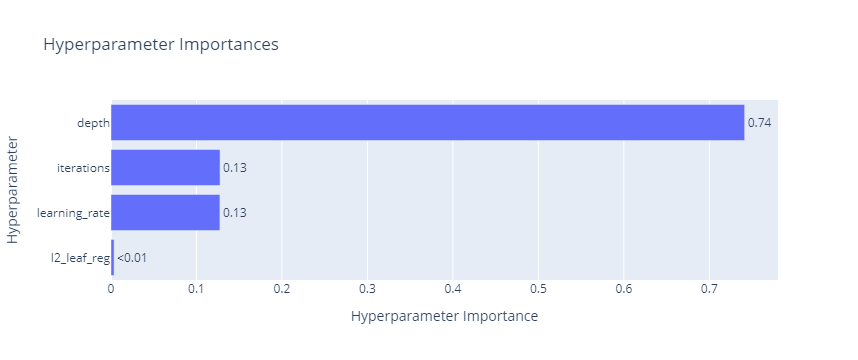

In [31]:
print(f"Number of trials on the Pareto front: {len(study.best_trials)}")
trial_with_highest_accuracy = max(study.best_trials, key=lambda t: t.values[0])
print(f"Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_accuracy.number}")
print(f"\tparams: {trial_with_highest_accuracy.params}")
print(f"\tvalues: {trial_with_highest_accuracy.values}")
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.values[0], target_name="auc"
)

### Building Optimal Model

In [13]:
# Optimal model
params = {
    'learning_rate': 0.015742881221129403,  
    'iterations': 2665,
    'l2_leaf_reg': 0.222046549398224,  
    'depth': 7,
    'random_seed': 53,
    'verbose': 0,
    'thread_count':15
}

catboost_model = CatBoostClassifier(**params)
valid_pool = Pool(X_val, y_val, cat_features=string_columns)#
catboost_model.fit(X_train, y_train, eval_set=valid_pool, verbose=0, plot=False, use_best_model=True, cat_features=string_columns)#, 

In [14]:
from sklearn.metrics import confusion_matrix

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]
    y_pred_val = model.predict_proba(X_val)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(catboost_model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)


ROC:  0.8713220173087418
1% Lift:  20.348703831153934
1% PPV:  1.5735641227380015
1% Sensitivity:  0.9176416609314062
10% Lift:  6.285845377380133
10% PPV:  1.6205797899539787
10% Sensitivity:  9.451709107593485


In [15]:
catboost_model.save_model('catboost_model.cbm', format = 'cbm')

Text(0.5, 427.9555555555555, 'Predicted label')

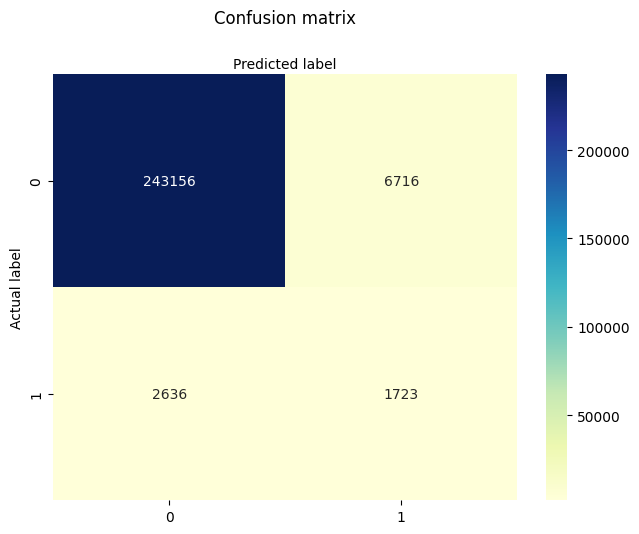

In [51]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = catboost_model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [52]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_pred_test_class, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.99      0.97      0.98    249872
     with IP       0.20      0.40      0.27      4359

    accuracy                           0.96    254231
   macro avg       0.60      0.68      0.63    254231
weighted avg       0.98      0.96      0.97    254231



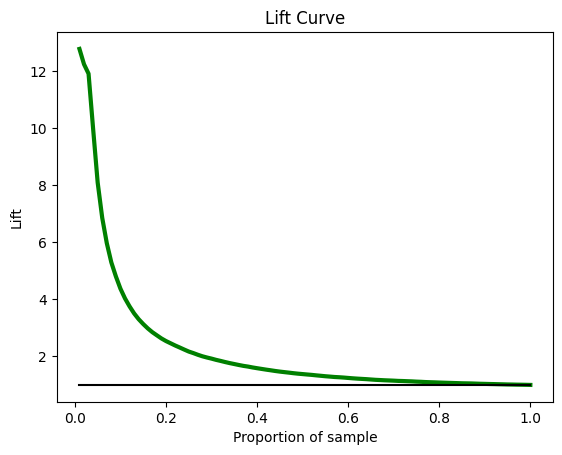

In [53]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
    
plot_lift_curve(y_test, y_pred_test_class, step=0.01)

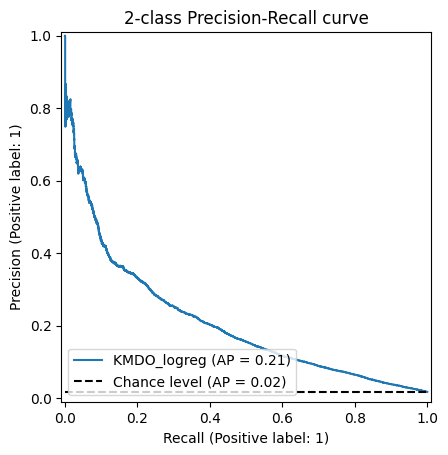

In [54]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    catboost_model, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [63]:
### PASTED OVER FROM GITHUB
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df
lift_chart= lift_chart(X_test, y_test, catboost_model)
lift_chart.to_csv('lift_chart_catboost.csv')
lift_chart

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.993394,0.732240,852,2543,1.000271,19.545767,19.545767,1.000271,19.540464
1,0.732132,0.610495,444,2542,0.999878,10.185822,29.731590,2.000149,14.864684
2,0.610463,0.521477,334,2542,0.999878,7.662308,37.393898,3.000028,12.464518
3,0.521469,0.458154,263,2543,1.000271,6.033494,43.427392,4.000299,10.856037
4,0.458146,0.407970,188,2542,0.999878,4.312916,47.740307,5.000177,9.547723
5,0.407957,0.365858,174,2542,0.999878,3.991741,51.732049,6.000055,8.621929
6,0.365792,0.331265,146,2543,1.000271,3.349392,55.081441,7.000326,7.868410
7,0.331258,0.301723,138,2542,0.999878,3.165864,58.247304,8.000205,7.280727
8,0.301717,0.276225,95,2542,0.999878,2.179399,60.426703,9.000083,6.714017
9,0.276224,0.255477,115,2543,1.000271,2.638220,63.064923,10.000354,6.306269


In [66]:
feature_importances = catboost_model.get_feature_importance() # Create a DataFrame to display feature names alongside their importance 
importance_df = pd.DataFrame({ 'Feature': X_train.columns, 'Importance': feature_importances }).sort_values(by='Importance', ascending=False) # Display the DataFrame 
pd.set_option("display.max_rows", None)
importance_df.to_csv('importance_df_catboost.csv')
importance_df

,Feature,Importance
195,agenbr,10.765821
0,coa_population_group,4.948259
199,tenure_yr1,3.943052
467,emb224,1.898525
49,coe_eval_clm_yr1,1.767924
123,major_chronic_cnt,1.350062
37,emis_spec_clm_yr1,1.222603
198,primarylanguage_desc,1.036026
226,water_quality,0.991038
324,emb81,0.886331
